In [1]:
import json
import pandas as pd
from pathlib import Path
from tqdm.auto import tqdm
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import numpy as np
import re

d:\VGU\2nd year\DSAI\Project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
root_path = Path('./Dataset/wYe7pBJ7-train/train') 
all_data = []

json_files = list(root_path.rglob('annotations.json'))

#Using tqdm to track progress
for j_path in tqdm(json_files, desc="Building Inventory and Blur Analysis"):
    try:
        with open(j_path, 'r') as f:
            data = json.load(f)
            plate_text = str(data.get('plate_text', ""))
            corners = data.get('corners', {})
            track_name = j_path.parent.name
            
            # Extract number for sorting
            track_num = int(re.search(r'\d+', track_name).group())
            
            if corners:
                #Scenario A
                for img_name, pts in corners.items():
                    img_path = j_path.parent / img_name
                    
                    #Calculate Blur (Laplacian Variance)
                    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
                    blur_score = cv2.Laplacian(img, cv2.CV_64F).var() if img is not None else None
                    
                    res_type = 'LR' if img_name.startswith('lr-') else 'HR'
                    w = pts['top-right'][0] - pts['top-left'][0]
                    h = pts['bottom-left'][1] - pts['top-left'][1]
                    
                    all_data.append({
                        'text': plate_text,
                        'x': pts['top-left'][0],     
                        'y': pts['top-left'][1],     
                        'width': w,                  
                        'height': h,                 
                        'area': w * h,               
                        'blur_score': blur_score,    
                        'type': res_type,
                        'scenario': 'A',
                        'folder': track_name,
                        'track_n': track_num
                    })
            else:
                #Scenario B
                #Loop through all images in the folder to get the blur scores
                for img_path in j_path.parent.glob('*.png'):
                    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
                    blur_score = cv2.Laplacian(img, cv2.CV_64F).var() if img is not None else None
                    
                    res_type = 'LR' if img_path.name.startswith('lr-') else 'HR'
                    
                    all_data.append({
                        'text': plate_text,
                        'x': None, 
                        'y': None, 
                        'width': None, 
                        'height': None, 
                        'area': None,
                        'blur_score': blur_score,
                        'type': res_type,
                        'scenario': 'B',
                        'folder': track_name,
                        'track_n': track_num
                    })
    except Exception as e:
        # It's good to log errors if any files are corrupted
        print(f"Error processing {j_path}: {e}")
        continue

if all_data:
    df_master = pd.DataFrame(all_data)
    
    #If 5th char is a letter -> Mercosur, else -> Old
    df_master['format'] = df_master['text'].apply(
        lambda x: 'Mercosur' if (len(str(x)) >= 5 and str(x)[4].isalpha()) else 'Old'
    )
    
    #Sort by track number and clean up
    df_master = df_master.sort_values(by=['track_n', 'type']).drop(columns=['track_n']).reset_index(drop=True)

    #Save the dataframe to CSV
    df_master.to_csv('plate_dataset_inventory_full.csv', index=False)
    print("Inventory built successfully.")

Building Inventory and Blur Analysis: 100%|██████████| 20000/20000 [24:04<00:00, 13.84it/s]


Inventory built successfully.


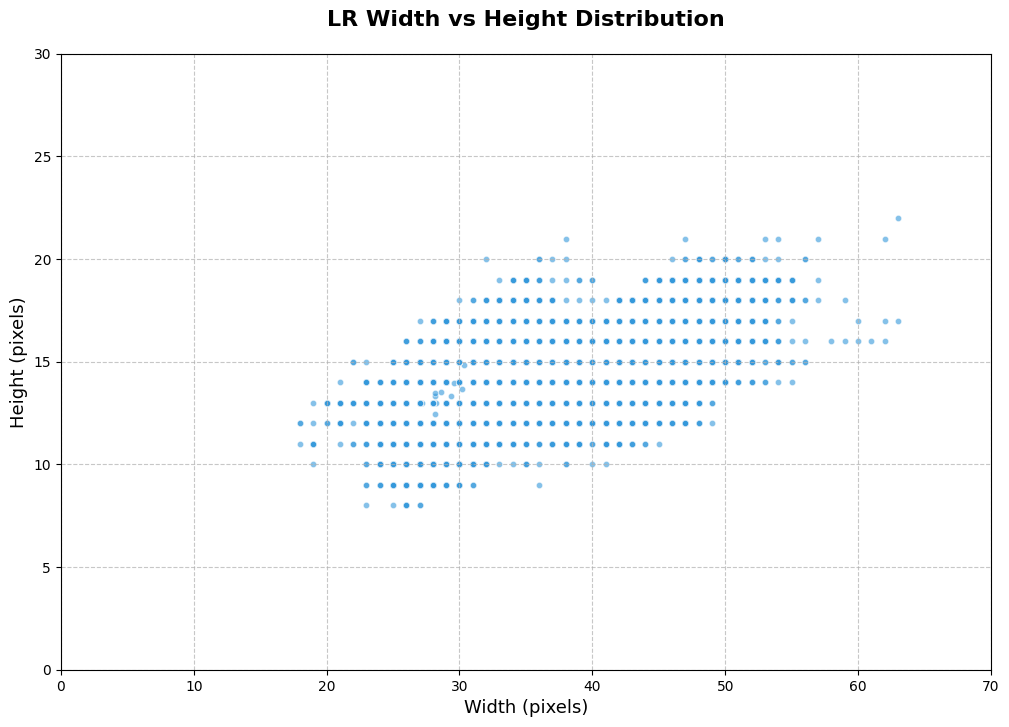

In [3]:
#Filter for Low Resolution
lr_data = df_master[df_master['type'] == 'LR']

plt.figure(figsize=(12, 8))

plt.scatter(lr_data['width'], lr_data['height'], 
            color='#3498db', 
            alpha=0.6, 
            s=20,
            edgecolors='white',
            linewidth=0.5)

plt.xlim(0, 70)
plt.ylim(0, 30)
plt.xticks(range(0, 71, 10))
plt.yticks(range(0, 31, 5))
plt.title('LR Width vs Height Distribution', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Width (pixels)', fontsize=13)
plt.ylabel('Height (pixels)', fontsize=13)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

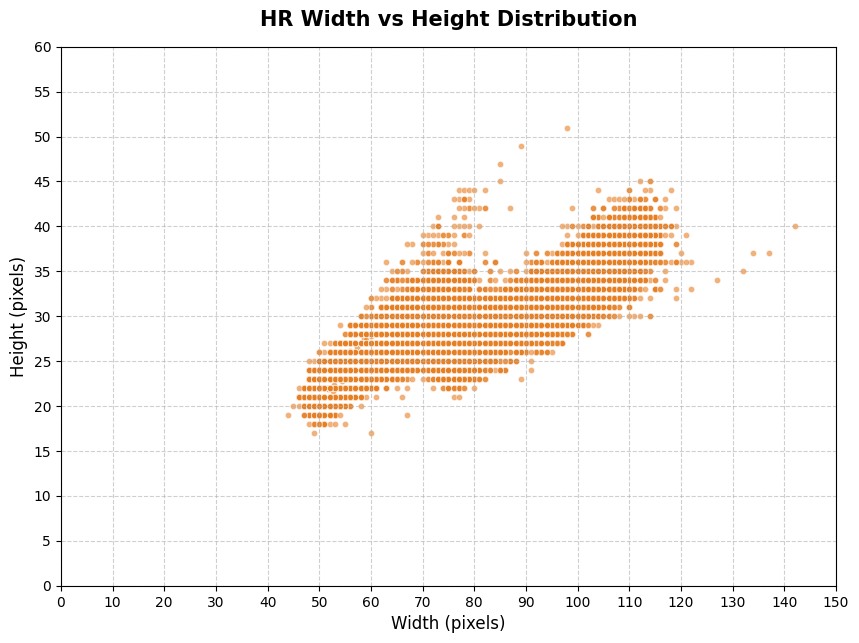

In [4]:
#Filter for High Resolution
hr_data = df_master[df_master['type'] == 'HR']

plt.figure(figsize=(10, 7))
plt.scatter(hr_data['width'], hr_data['height'], 
            color='#e67e22', 
            alpha=0.6, 
            s=20, 
            edgecolors='white',
            linewidth=0.5)

plt.xlim(0, 150) 
plt.ylim(0, 60)
plt.xticks(range(0, 151, 10))
plt.yticks(range(0, 61, 5))

plt.title('HR Width vs Height Distribution', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Width (pixels)', fontsize=12)
plt.ylabel('Height (pixels)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

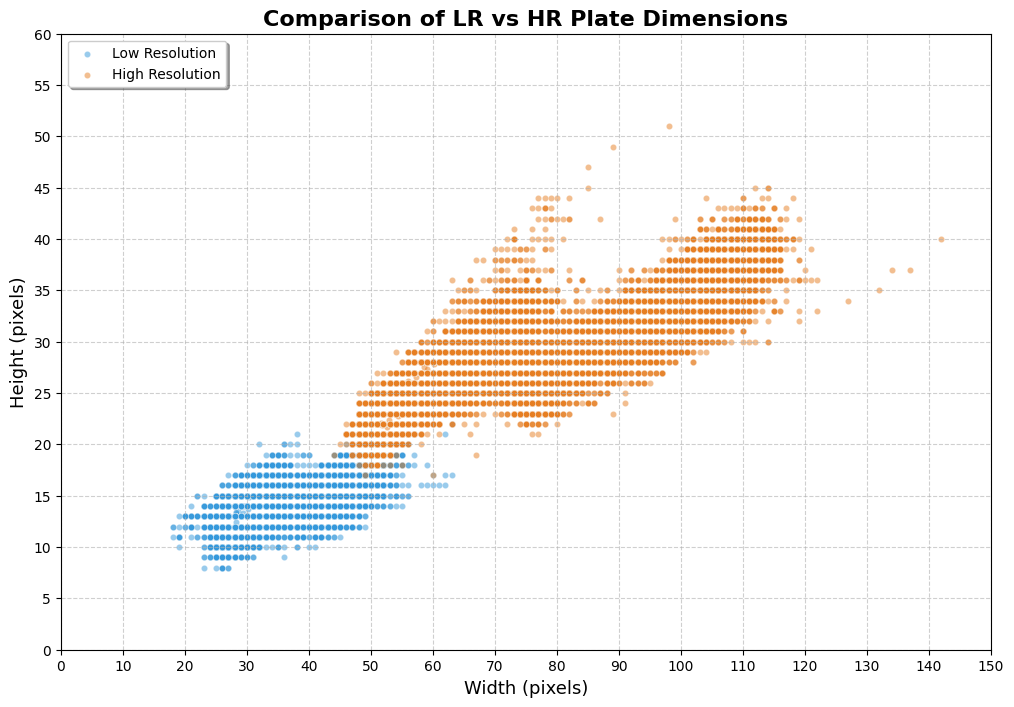

In [5]:
lr_data = df_master[df_master['type'] == 'LR']
hr_data = df_master[df_master['type'] == 'HR']
plt.figure(figsize=(12, 8))

plt.scatter(lr_data['width'], lr_data['height'], 
            color='#3498db',
            alpha=0.5, 
            s=20, 
            label='Low Resolution', 
            edgecolors='white', 
            linewidth=0.3)

plt.scatter(hr_data['width'], hr_data['height'], 
            color='#e67e22', 
            alpha=0.5, 
            s=20, 
            label='High Resolution', 
            edgecolors='white', 
            linewidth=0.3)

plt.xlim(0, 150)
plt.ylim(0, 60)
plt.xticks(range(0, 151, 10))
plt.yticks(range(0, 61, 5))

plt.title('Comparison of LR vs HR Plate Dimensions', fontsize=16, fontweight='bold')
plt.xlabel('Width (pixels)', fontsize=13)
plt.ylabel('Height (pixels)', fontsize=13)
plt.legend(loc='upper left', frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Unique Plates found: 6946


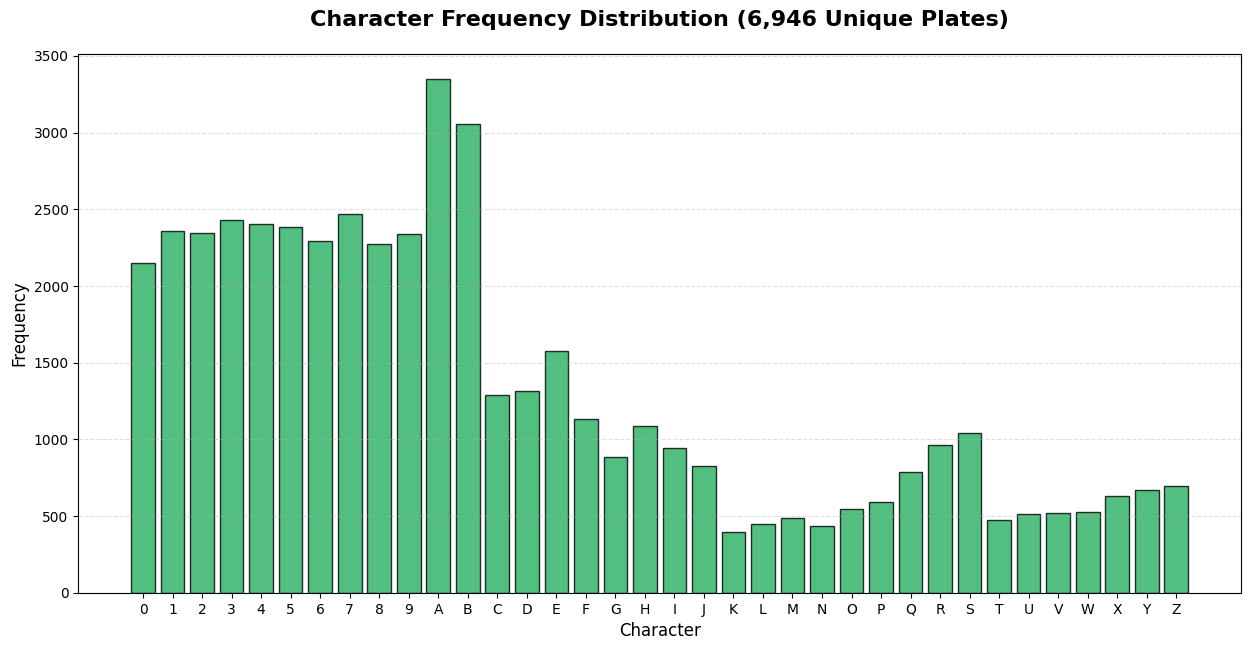

In [8]:
#Ensure text is string and stripped of any hidden spaces
df_master['text'] = df_master['text'].astype(str).str.strip().str.upper()

#Filter for non-empty text
valid_df = df_master[df_master['text'] != ""]

#Get unique plates based on the TEXT string
df_unique = valid_df.drop_duplicates(subset=['text'])

current_unique = len(df_unique)
print(f"Unique Plates found: {current_unique}")

all_text = "".join(df_unique['text'])
char_counts = Counter(all_text)

sorted_chars = sorted(char_counts.items())
chars, counts = zip(*sorted_chars)

plt.figure(figsize=(15, 7))
plt.bar(chars, counts, color='#27ae60', edgecolor='black', alpha=0.8)

plt.title(f'Character Frequency Distribution ({current_unique:,} Unique Plates)', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Character', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.xticks(fontsize=10)
plt.show()

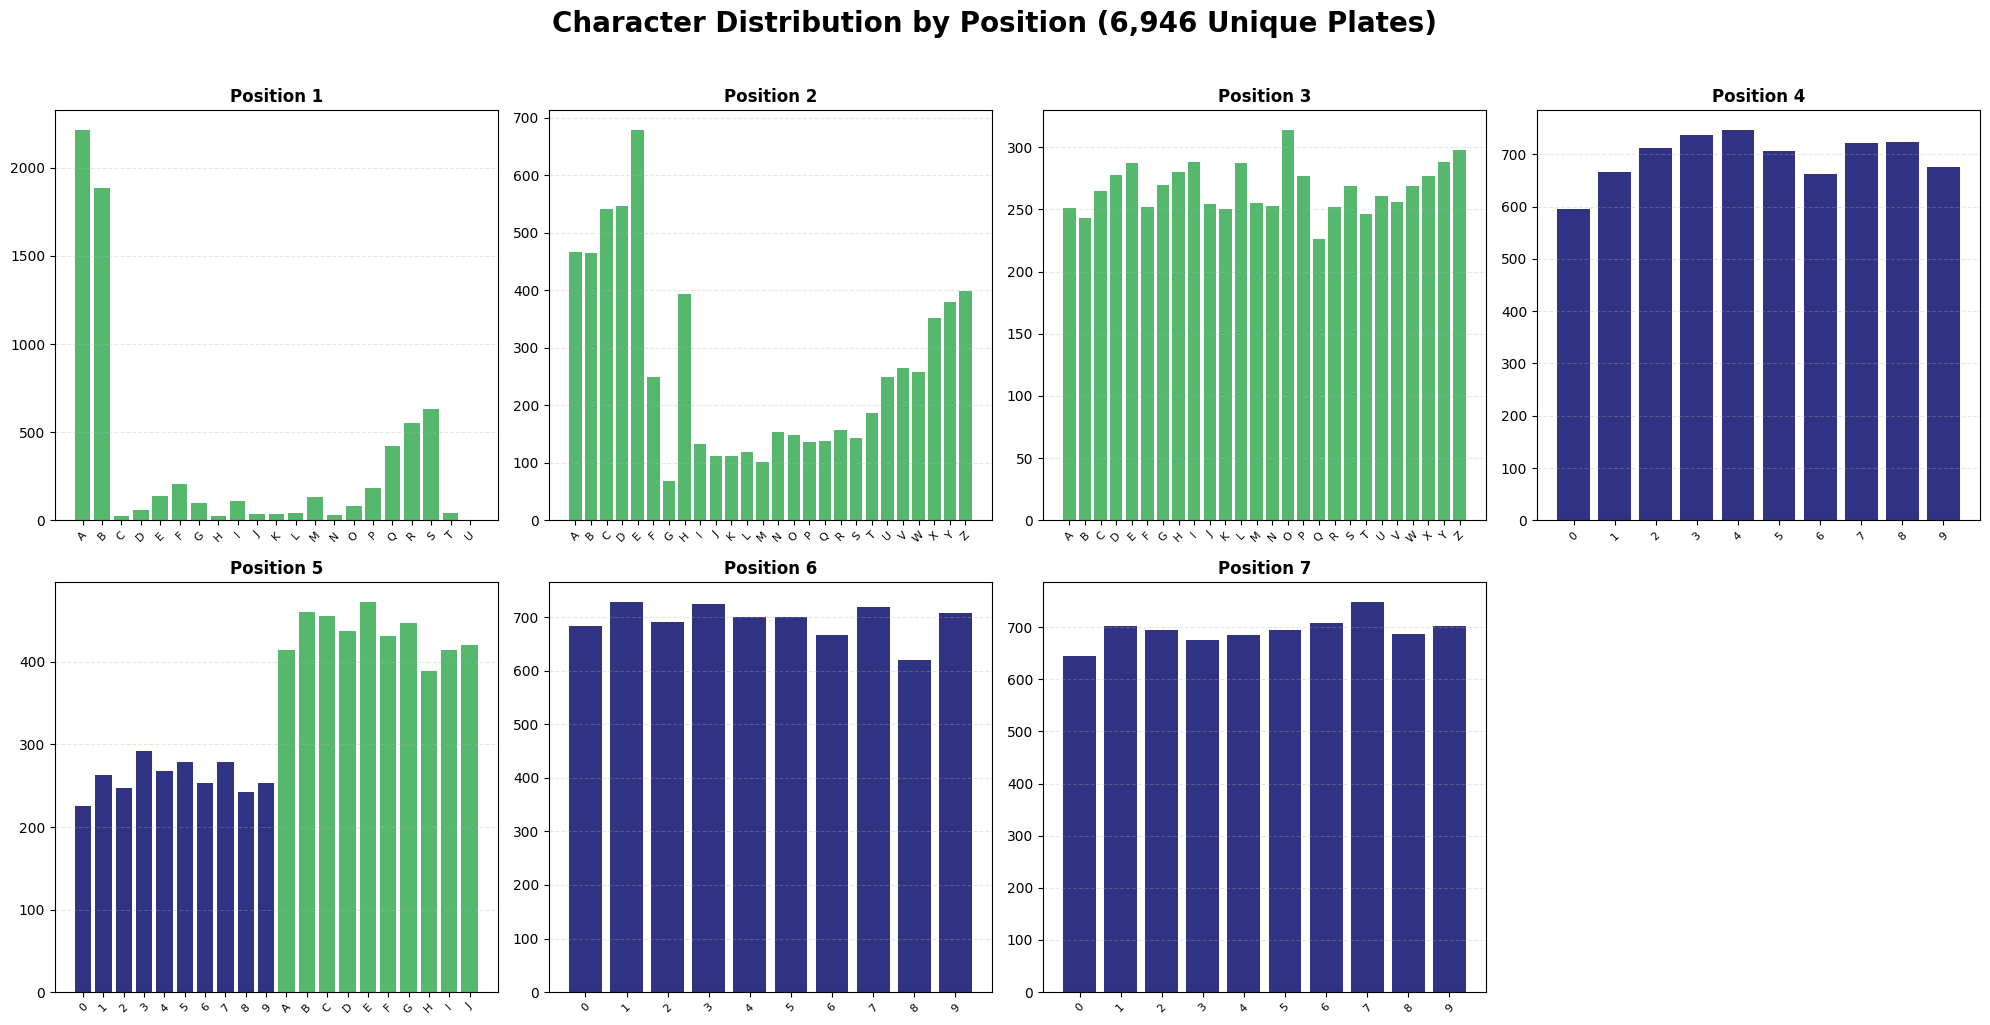

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

unique_plates = df_master.drop_duplicates(subset=['text'])

for i in range(7):
    # Extract characters at this position and count them
    chars_at_pos = unique_plates['text'].str[i].dropna()
    counts = Counter(chars_at_pos)
    
    if not counts:
        continue
        
    sorted_keys = sorted(counts.keys())
    values = [counts[k] for k in sorted_keys]
    
    colors = ['#55b86d' if str(k).isalpha() else '#303383' for k in sorted_keys]
    
    axes[i].bar(sorted_keys, values, color=colors)
    axes[i].set_title(f'Position {i+1}', fontweight='bold')
    axes[i].tick_params(axis='x', labelsize=8, rotation=45)
    axes[i].grid(axis='y', linestyle='--', alpha=0.3)

fig.delaxes(axes[7])

plt.suptitle(f'Character Distribution by Position ({len(unique_plates):,} Unique Plates)', 
             fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

C:\Users\An\AppData\Local\Temp\ipykernel_24688\258993234.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_master, x='format', palette='Set2')


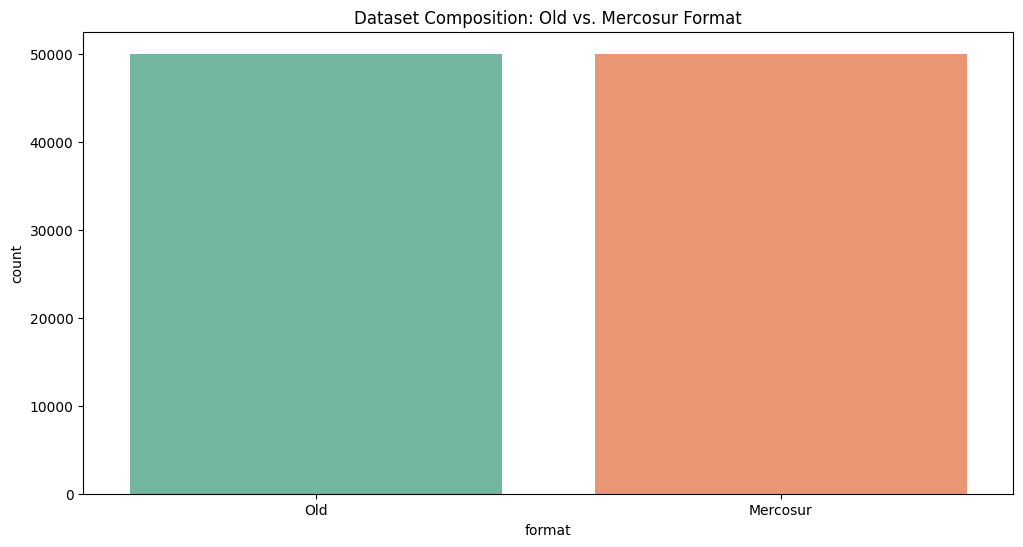

In [11]:
#Format Split
df_master['format'] = df_master['text'].apply(lambda x: 'Mercosur' if (len(x) > 4 and x[4].isalpha()) else 'Old')

#Character Position Heatmap
char_data = []
for text in df_master['text'].unique():
    if len(text) == 7:
        char_data.append(list(text))

df_chars = pd.DataFrame(char_data, columns=[f'Pos_{i+1}' for i in range(7)])

plt.figure(figsize=(12, 6))

# Focus on the 5th position complexity
sns.countplot(data=df_master, x='format', palette='Set2')
plt.title("Dataset Composition: Old vs. Mercosur Format")
plt.show()

In [8]:
#About Brazilian License Plates:
#Brazilian license plates follow a specific format of 3 letters followed by 4 characters (e.g., ABC1234).
#The first 3 letters represent the state code, where the car is registered.
#The reason there's such a big spike for A and B is probably because the dataset uses a lot of plates from the states of São Paulo and Paraná.
#Before 2018, Brazilian plates follow the format of 3 letters followed by 4 numbers (e.g., ABC1234).
#After 2018, they switched to the new Mercosul format of 3 letters followed by 1 number, then 1 letter, then 2 numbers (e.g., ABC1D23)
#That explains why the 5th position has a mix of letters and numbers, while 4th 6th and 7th are numbers only. 

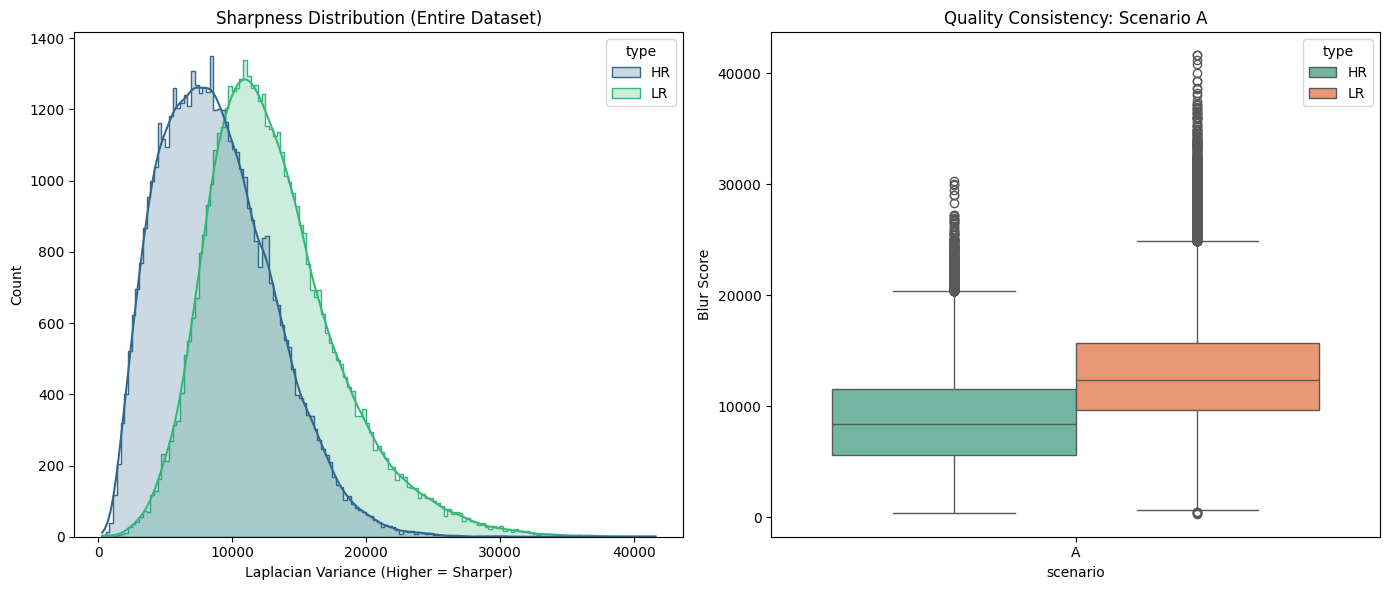

In [13]:
plt.figure(figsize=(14, 6))

#Distribution of blurriness
plt.subplot(1, 2, 1)
sns.histplot(data=df_master, x='blur_score', hue='type', element="step", kde=True, palette='viridis')
plt.title("Sharpness Distribution (Entire Dataset)")
plt.xlabel("Laplacian Variance (Higher = Sharper)")

#HR vs LR Comparison by Scenario
plt.subplot(1, 2, 2)
sns.boxplot(data=df_master, x='scenario', y='blur_score', hue='type', palette='Set2')
plt.title("Quality Consistency: Scenario A")
plt.ylabel("Blur Score")

plt.tight_layout()
plt.show()